/var/folders/h3/gxsg9l7j7yb4ks48250kxs900000gn/T/ipykernel_35763/4061782760.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(symbol, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


Last Price: 16.973947525024414, Annualized Drift (mu): 0.1236, Annualized Volatility (sigma): 0.2989
Estimated European Call Option Price: 1.75


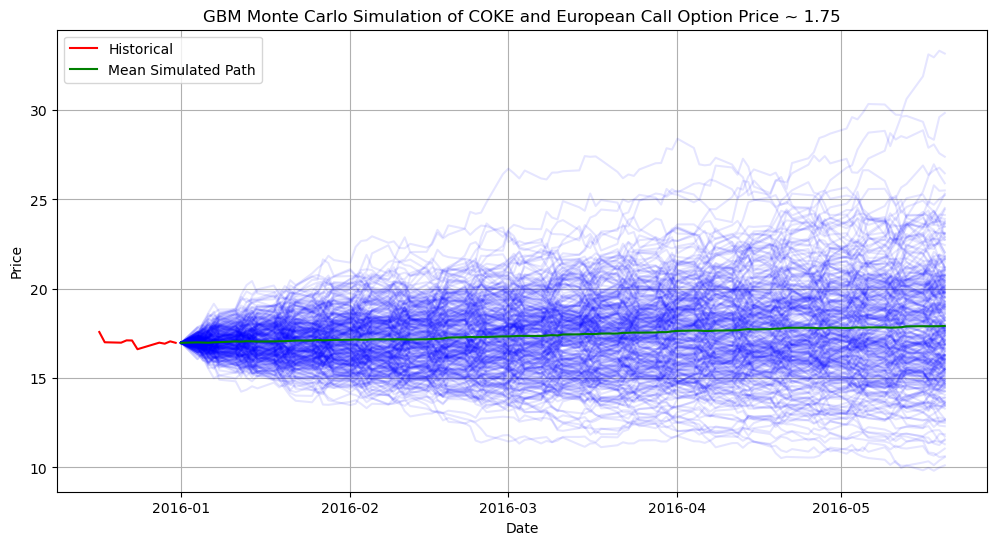

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# PARAMETERS
# -------------------------------
symbol = "COKE"
start = "2005-01-01"
end = "2016-01-01"

n_days = 100        # number of days to simulate
n_paths = 300        # number of Monte Carlo paths


raw_data = yf.download(symbol, start=start, end=end)
raw_data.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in raw_data.columns]
close_col = f"Close_{symbol}"
S0 = raw_data[close_col].iloc[-1]  # current price

# Calculate historical daily log returns
returns = np.log(raw_data[close_col] / raw_data[close_col].shift(1)).dropna()
mu = returns.mean() * 252       # annualized drift
sigma = returns.std() * np.sqrt(252)  # annualized volatility

print(f"Last Price: {S0}, Annualized Drift (mu): {mu:.4f}, Annualized Volatility (sigma): {sigma:.4f}")

K = S0             # strike price for the option, S0 so at the money option
r = 0.05             # risk-free annual rate
dt = 1/252           # time step in years (~252 trading days per year)
T = n_days * dt      # total time to maturity in years


def simulate_gbm(S0, mu, sigma, T, dt, n_paths):
    n_steps = int(T/dt)
    # Preallocate array
    S = np.zeros((n_steps + 1, n_paths))
    S[0] = S0
    # Simulate GBM paths
    for t in range(1, n_steps + 1):
        Z = np.random.normal(0, 1, n_paths)
        S[t] = S[t-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
    return S

sim_paths = simulate_gbm(S0, mu, sigma, T, dt, n_paths)

# -------------------------------
# OPTION PRICE CALCULATION (European Call)
# -------------------------------
# Terminal prices
S_T = sim_paths[-1, :]
# Payoff at expiration
payoffs = np.maximum(S_T - K, 0)
# Discount to present
option_price = np.exp(-r * T) * np.mean(payoffs)

print(f"Estimated European Call Option Price: {option_price:.2f}")

# -------------------------------
# PLOTTING
# -------------------------------
future_dates = pd.bdate_range(start=raw_data.index[-1] + pd.Timedelta(days=1), periods=sim_paths.shape[0])
sim_df = pd.DataFrame(sim_paths, index=future_dates)

plt.figure(figsize=(12,6))
plt.plot(sim_df, color='blue', alpha=0.1)
plt.plot(raw_data[close_col].iloc[-10:], color='red', label='Historical')
plt.plot(sim_df.mean(axis=1), color='green', label='Mean Simulated Path')
plt.xlabel("Date")
plt.ylabel("Price")
plt.title(f"GBM Monte Carlo Simulation of {symbol} and European Call Option Price ~ {option_price:.2f}")
plt.grid(True)
plt.legend()
plt.show()
